In [1]:
# importaciones
import pandas as pd
import matplotlib.pyplot as plt

# 1. No limitar el número de columnas al mostrar
pd.set_option('display.max_columns', None)

# 2. No saltar de línea aunque la tabla sea muy ancha
pd.set_option('display.expand_frame_repr', False)

# 3. Esto hace que las gráficas se vean más modernas
plt.style.use('ggplot')

print('Toda las importaciones funciono')

KeyboardInterrupt: 

In [18]:
# Cargar datos
df = pd.read_csv('netflix_titles.csv')
print(df)

# Usamos .copy() al final para que sea un objeto totalmente independiente y .dropna() para eliminar las columnas con campos con Null
df_limpio = df.dropna().copy()

# Reajustas los índices (opcional pero recomendado)
df_limpio = df_limpio.reset_index(drop=True)

#  Cantidad de filas con registros antes de limpiar
print(f"Filas originales: {len(df)}")

#  Cantidad de filas con registros despues de limpiar
print(f"Filas después de limpiar: {len(df_limpio)}")

     show_id     type                  title         director                                               cast        country          date_added  release_year rating   duration                                          listed_in                                        description
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson                                                NaN  United States  September 25, 2021          2020  PG-13     90 min                                      Documentaries  As her father nears the end of his life, filmm...
1         s2  TV Show          Blood & Water              NaN  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa  September 24, 2021          2021  TV-MA  2 Seasons    International TV Shows, TV Dramas, TV Mysteries  After crossing paths at a party, a Cape Town t...
2         s3  TV Show              Ganglands  Julien Leclercq  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN  September 24, 2021       

In [14]:
# ¿Domina el catálogo películas o series?
series = (df_limpio['type'] == 'TV Show').sum()
movies = (df_limpio['type'] == 'Movie').sum()

if series > movies:
    print(f'las series dominan con un total de {series} registros')
else:
    print(f'las peliculas dominan con un total de {movies} registros')

las peliculas dominan con un total de 5185 registros


In [15]:
# ¿Qué países generan más contenido?
# value_counts() cuenta la frecuencia de valores únicos en una columna, mostrando cuántas veces aparece cada elemento, ignorando valores nulos por defecto.
df_limpio['country'].value_counts()


country
United States                                     1846
India                                              875
United Kingdom                                     183
Canada                                             107
Spain                                               91
                                                  ... 
Germany, United States, United Kingdom, Canada       1
United States, East Germany, West Germany            1
Egypt, Austria, United States                        1
Croatia, Slovenia, Serbia, Montenegro                1
United Arab Emirates, Jordan                         1
Name: count, Length: 604, dtype: int64

In [19]:
# ¿Cómo ha evolucionado el catálogo en el tiempo?
df_limpio['date_added'] = pd.to_datetime(df_limpio['date_added'])
df_limpio['year_added'] = df_limpio['date_added'].dt.year
df_limpio.groupby(['year_added', 'type']).size().unstack()

# El catálogo ha aumentado significativamente con el tiempo.
# Aunque las películas muestran un crecimiento con fluctuaciones,
# las series presentan una tendencia de crecimiento más sostenida en los últimos años.

ValueError: time data " August 4, 2017" doesn't match format "%B %d, %Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
# ¿Qué tipo de contenido debería priorizar Netflix?
# Convertir a fecha 
# df_limpio = df_limpio.dropna(subset=['date_added'])
df_limpio['date_added'] = pd.to_datetime(df_limpio['date_added'])

# Extraer el año
df_limpio['year_added'] = df_limpio['date_added'].dt.year

# Agrupamos por año y tipo
# df_limpio.groupby(['year_added', 'type']).size().reset_index()
df_limpio.groupby(['year_added', 'type']).size().unstack()

# Aunque las películas dominan en cantidad total, las series han mostrado un crecimiento más acelerado en los últimos años, 
# lo que sugiere que Netflix está apostando estratégicamente por este tipo de contenido y debería continuar priorizándolo.

type,Movie,TV Show
year_added,,
2008,1.0,NaN
2009,2.0,NaN
2010,1.0,NaN
2011,13.0,NaN
2012,3.0,NaN
2013,6.0,1.0
2014,14.0,NaN
2015,47.0,3.0
2016,195.0,7.0


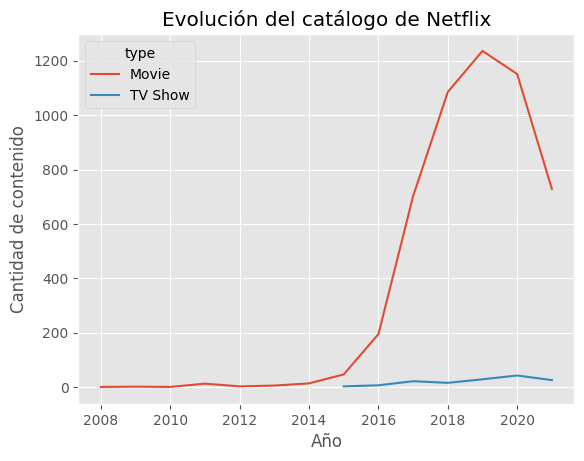

In [ ]:
# Grafica pregunta 3 y 4
df_plot = df_limpio.groupby(['year_added', 'type']).size().unstack()
df_plot.plot()

plt.title('Evolución del catálogo de Netflix')
plt.xlabel('Año')
plt.ylabel('Cantidad de contenido')
plt.show()

In [ ]:
df_plot.plot(figsize=(10,6), marker='o', kind='line')

plt.title('Evolución del catálogo de Netflix', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Cantidad de contenido')
plt.legend(title='Tipo de contenido')
plt.grid(True)

plt.show()

NameError: name 'df_plot' is not defined